<a href="https://colab.research.google.com/github/Suthirtha2004/ml-from-scratch/blob/main/Classification_Gradient_Descent_and_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Logistic/Sigmoid Function**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
input_arr = np.array([1,2,3])
exp_arr = np.exp(input_arr)

print(f"Input array : {input_arr}")
print(f"Output array : {exp_arr}")

Input array : [1 2 3]
Output array : [ 2.71828183  7.3890561  20.08553692]


In [ ]:
# Sigmoid Function

def sigmoid(z):
  """
    Computes the sigmoid function of the z
    Arguments :

    z : ndarray(n,) of size n
    Output :
    g : ndarray() same shape as z
  """

  g = 1/(1 + np.exp(-z))
  return g

Input values : [-10  -9  -8  -7  -6  -5  -4  -3  -2  -1   0   1   2   3   4   5   6   7
   8   9  10]
Output values : [4.540e-05 1.234e-04 3.354e-04 9.111e-04 2.473e-03 6.693e-03 1.799e-02
 4.743e-02 1.192e-01 2.689e-01 5.000e-01 7.311e-01 8.808e-01 9.526e-01
 9.820e-01 9.933e-01 9.975e-01 9.991e-01 9.997e-01 9.999e-01 1.000e+00]


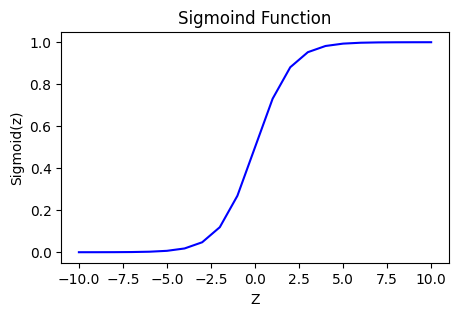

In [ ]:
x_in = np.arange(-10,11)
y = sigmoid(x_in)

np.set_printoptions(precision=3)
print(f"Input values : {x_in}")
print(f"Output values : {y}")

# Plot of x vs sigmoid(x)

fig,ax = plt.subplots(1,1,figsize=(5,3))
ax.plot(x_in,y,c="b")
ax.set_title("Sigmoind Function")
ax.set_xlabel("Z")
ax.set_ylabel("Sigmoid(z)")
plt.show()



Cost Function Classification


In [ ]:
x_train = np.array([[0.5,1.5],[1,1],[1.5,0.5],[3,0.5],[2,2],[1,2.5]])
y_train = np.array([0,0,0,1,1,1]) # This is a custom dataset

In [ ]:
def sigmoid(z):
  """
  z : ndarray() : m,n paramters
  g : ndarray() : Output
  """

  g = 1/(1+np.exp(-z))
  return g

In [ ]:
def compute_cost_logistic(X,y,w,b):
  """
  Computes cost

  Args:
    X(ndarray(m,n)) : m examples with n features
    y(ndarray(m,)) : m output values
    w(ndarray(m,0)) : model parameter
    b(scalar) : model parameter

  Returns :
    cost(scalar value)
  """

  m = X.shape[0]
  cost = 0.0
  for i in range(m):
    z_i = np.dot(X[i],w) + b
    fwb_i = sigmoid(z_i)
    cost += -y[i]*np.log(fwb_i) - (1-y[i])*np.log(1- fwb_i)

  cost = cost/m
  return cost

In [ ]:
# Testing Purpose

w_tmp = np.array([1,1])
b_tmp = -3

print(compute_cost_logistic(x_train,y_train,w_tmp,b_tmp))

0.36686678640551745


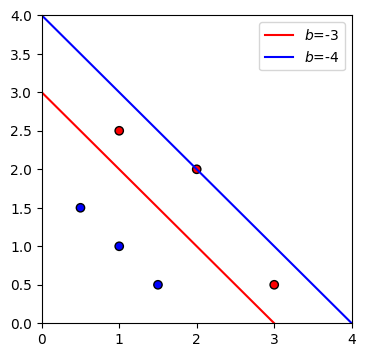

In [ ]:
# Plotting values of Different decision boundaries

x0 = np.arange(0,6)

#Plot the two decision boundaries
x1 = 3-x0
x2 = 4-x0

fig,ax = plt.subplots(1,1,figsize=(4,4))

ax.plot(x0,x1,c="red",label="$b$=-3")
ax.plot(x0,x2,c="blue",label="$b$=-4")

ax.scatter(x_train[:, 0], x_train[:, 1], c=y_train, cmap="bwr", edgecolor="k")
ax.axis([0,4,0,4])

plt.legend()
plt.show()


In [ ]:
# Checking cost to determine the best parameters

w_arr1 = np.array([1,1])
b_1 = -3
w_arr2 = np.array([1,1])
b_2 = -4

print("Cost for b=-3",compute_cost_logistic(x_train,y_train,w_arr1,b_1))
print("Cost for b=-4",compute_cost_logistic(x_train,y_train,w_arr2,b_2))

Cost for b=-3 0.36686678640551745
Cost for b=-4 0.5036808636748461


Gradient Descent for Logistic Regression

In [ ]:
def compute_gradient_derivate(X,y,w,b):
  """
  Computes the gradient for the func

  Args:

  X(ndarray(m,n)) : Data m examples with n features
  y(ndarray(m,)) : target values
  w(ndarray(n,)) : Model paramters
  b(scalar) : model parameter

  Return:
    dj_dw(ndarray(n,0)) : The gradient of the cost w.r.t the paramters w
    dj_db(scalar) : The gradient of the cost w.r.t the paramter b
  """
  m,n = X.shape
  dj_dw = np.zeros((n,))
  dj_db = 0

  for i in range(m):
    fwb_i = sigmoid(np.dot(X[i],w)+b)
    err_i = fwb_i - y[i]
    for j in range(n):
      dj_dw[j] = dj_dw[j] + err_i*X[i,j]

    dj_db = dj_db + err_i

  dj_dw = dj_dw/m
  dj_db = dj_db/m

  return dj_dw,dj_db


In [ ]:
X_tmp = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_tmp = np.array([0, 0, 0, 1, 1, 1])
w_tmp = np.array([2.,3.])
b_tmp = 1
dj_dw_tmp,dj_db_tmp = compute_gradient_derivate(X_tmp,y_tmp,w_tmp,b_tmp)
print(f"dj_db : {dj_db_tmp}")
print(f"dj_dw : {dj_dw_tmp.tolist()}")

dj_db : 0.49861806546328574
dj_dw : [0.498333393278696, 0.49883942983996693]


In [ ]:
import copy
import math


def gradient_descent(x,y,w_in,b_in,alpha,num_iters):
  """
  Performs the batch gradient descent

  Args:
  x(ndarray(m,n))
  y(ndarray(m,))
  w_in(ndarray(n,))
  b_in(scalar)
  alpha(float) : learning rate
  num_iters(scalar) : No of iterations to run grad des

  Returns:
  w(ndarray(n,)) : Updated model paramters
  b(scalar) : Updated model paramters

  """

  J_hist = []
  w = copy.deepcopy(w_in)
  b= b_in

  for i in range(num_iters):

    dj_dw ,dj_db = compute_gradient_derivate(x,y,w,b)

    w= w - alpha * dj_dw
    b = b - alpha*dj_db

    if i< 100000:
      J_hist.append(compute_cost_logistic(x,y,w,b))

    if i % math.ceil(num_iters/10) == 0:
      print(f"Iteration {i:4d} : Cost {J_hist[-1]}")

  return w,b,J_hist




In [ ]:
w_tmp = np.zeros_like(x_train[0])
b_tmp = 0.
alpha = 0.1
iters = 10000

w_out,b_out,_ = gradient_descent(x_train,y_train,w_tmp,b_tmp,alpha,iters)
print(f"\nUpdated paramters : w : {w_out} , b : {b_out}")

Iteration    0 : Cost 0.684610468560574
Iteration 1000 : Cost 0.1590977666870457
Iteration 2000 : Cost 0.08460064176930078
Iteration 3000 : Cost 0.05705327279402531
Iteration 4000 : Cost 0.04290759421682
Iteration 5000 : Cost 0.03433847729884557
Iteration 6000 : Cost 0.02860379802212006
Iteration 7000 : Cost 0.02450156960879306
Iteration 8000 : Cost 0.02142370332569295
Iteration 9000 : Cost 0.019030137124109114

Updated paramters : w : [5.28123029 5.07815608] , b : -14.222409982019837
